## Cell 1 — Import library

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import networkx as nx

## Cell 2 — Tentukan folder project

In [2]:
PROJECT_ROOT = Path.cwd()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"
OUTPUT_FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"

OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Processed dir:", PROCESSED_DIR)
print("Output tables dir:", OUTPUT_TABLES_DIR)
print("Output figures dir:", OUTPUT_FIGURES_DIR)

Project root: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL
Processed dir: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\data\processed
Output tables dir: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\tables
Output figures dir: e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures


## Cell 3 — Baca full log, compact log, dan transisi

In [3]:
FULL_LOG_PATH = PROCESSED_DIR / "04_full_log_process_ready.csv"
COMPACT_LOG_PATH = PROCESSED_DIR / "04_compact_log_process_ready.csv"

TRANSITIONS_FULL_PATH = OUTPUT_TABLES_DIR / "04_transitions_full_log.csv"
TRANSITIONS_COMPACT_PATH = OUTPUT_TABLES_DIR / "04_transitions_compact_log.csv"

event_log_full = pd.read_csv(FULL_LOG_PATH, parse_dates=["timestamp"])
event_log_compact = pd.read_csv(COMPACT_LOG_PATH, parse_dates=["timestamp"])

transitions_full = pd.read_csv(TRANSITIONS_FULL_PATH)
transitions_compact = pd.read_csv(TRANSITIONS_COMPACT_PATH)

print("Full log:", event_log_full.shape)
print("Compact log:", event_log_compact.shape)
print("Transitions full:", transitions_full.shape)
print("Transitions compact:", transitions_compact.shape)

display(transitions_compact.head(10))

Full log: (147249, 17)
Compact log: (116611, 18)
Transitions full: (177, 3)
Transitions compact: (164, 3)


,source,target,frequency
0,Quiz Viewed,Quiz Updated,38709
1,Quiz Updated,Quiz Viewed,35519
2,Quiz Module Viewed,Course Viewed,2990
3,Quiz Updated,Quiz Auto-saved,2864
4,Quiz Auto-saved,Quiz Viewed,2853
5,Course Viewed,Material Viewed,2824
6,Material Viewed,Course Viewed,2434
7,Course Viewed,Quiz Module Viewed,2228
8,Quiz Updated,Quiz Summary Viewed,2180
9,Quiz Module Viewed,Quiz Viewed,1991


## Cell 4 — Fungsi filter transisi top-N

In [4]:
def get_top_transitions(transitions_df, top_n=20):
    top_transitions = transitions_df.head(top_n).copy()
    return top_transitions

## Cell 5 — Fungsi membuat DFG

In [5]:
def plot_dfg(transitions_df, title, output_path=None, top_n=20):
    top_transitions = get_top_transitions(transitions_df, top_n=top_n)

    G = nx.DiGraph()

    for _, row in top_transitions.iterrows():
        source = row["source"]
        target = row["target"]
        frequency = row["frequency"]

        G.add_edge(source, target, weight=frequency)

    plt.figure(figsize=(16, 10))

    pos = nx.spring_layout(
        G,
        k=1.2,
        iterations=100,
        seed=42
    )

    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    max_weight = max(edge_weights)

    edge_widths = [
        1 + (weight / max_weight) * 5
        for weight in edge_weights
    ]

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=3000,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=20,
        width=edge_widths,
        alpha=0.6,
        connectionstyle="arc3,rad=0.08"
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=9,
        font_weight="bold"
    )

    edge_labels = {
        (u, v): G[u][v]["weight"]
        for u, v in G.edges()
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=8
    )

    plt.title(title, fontsize=16)
    plt.axis("off")
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

## Cell 6 — DFG full log top 20

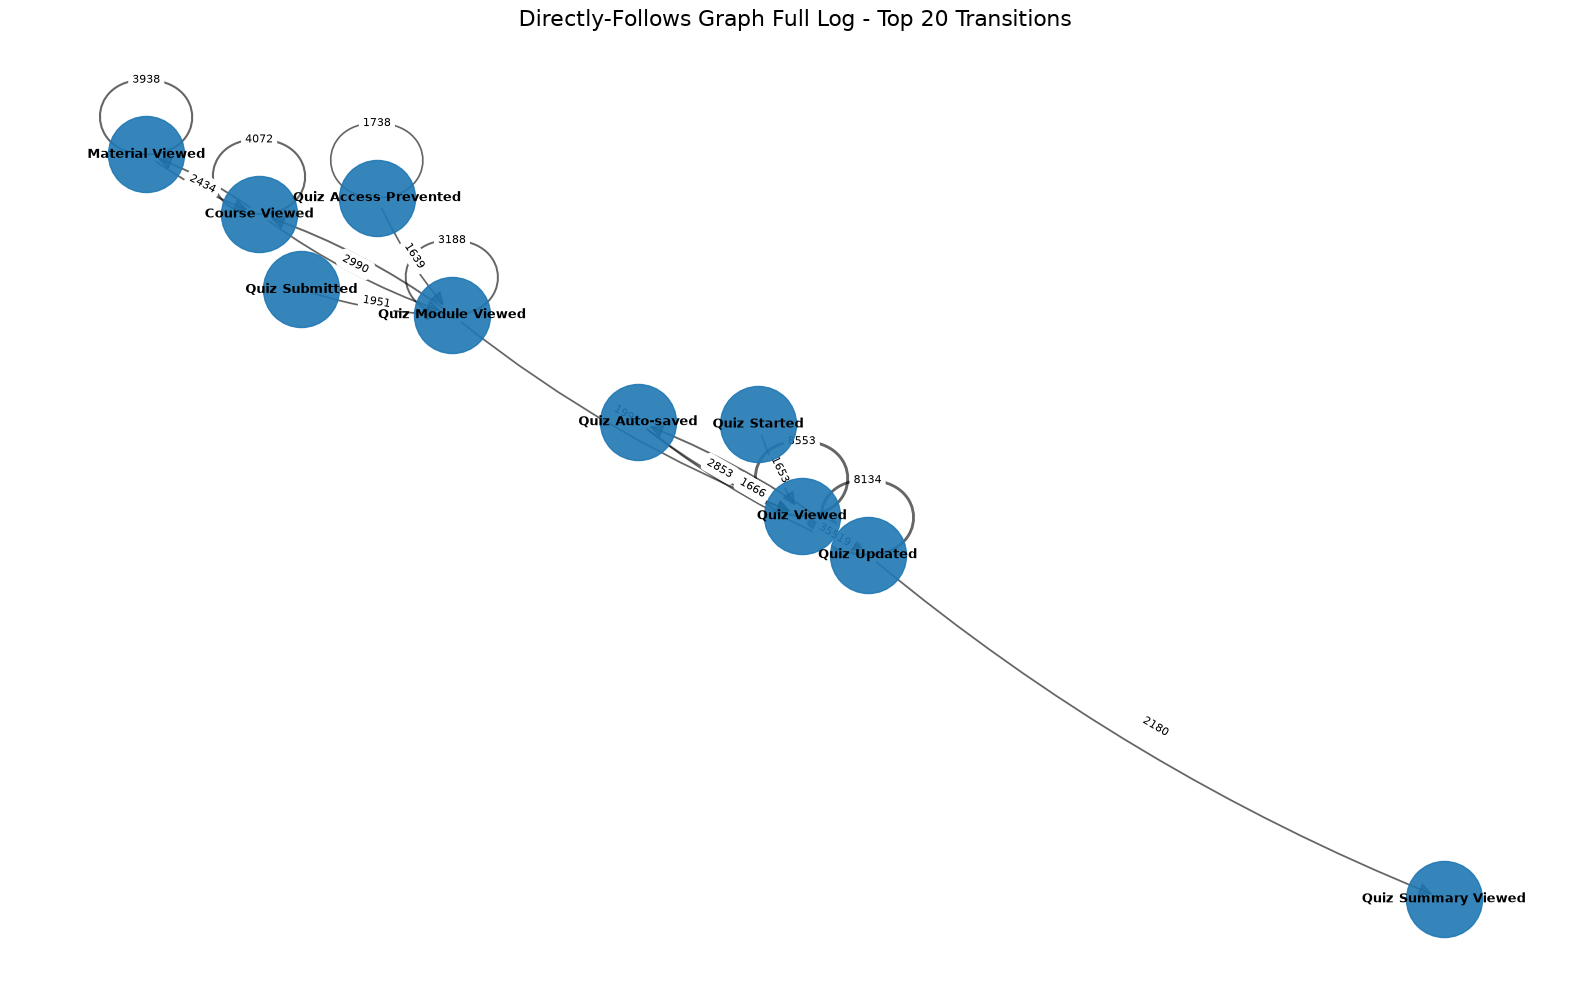

In [6]:
plot_dfg(
    transitions_full,
    title="Directly-Follows Graph Full Log - Top 20 Transitions",
    output_path=OUTPUT_FIGURES_DIR / "05_dfg_full_log_top20.png",
    top_n=20
)

## Cell 7 — DFG compact log top 20

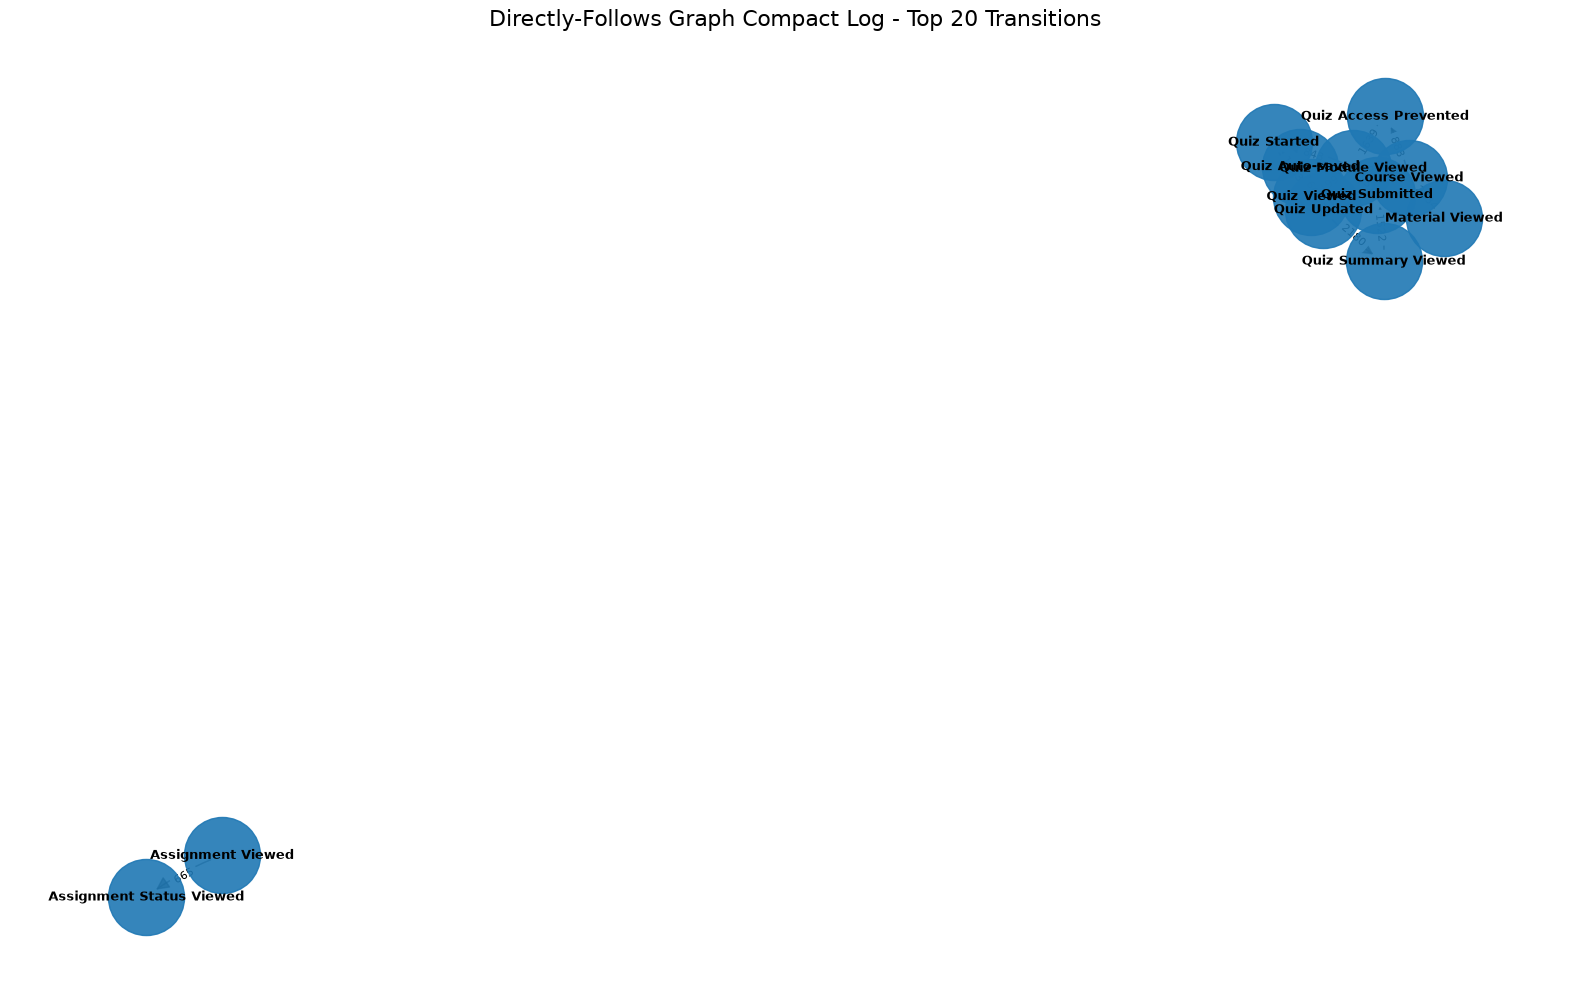

In [10]:
plot_dfg(
    transitions_compact,
    title="Directly-Follows Graph Compact Log - Top 20 Transitions",
    output_path=OUTPUT_FIGURES_DIR / "05_dfg_compact_log_top20.png",
    top_n=20
)

## Cell 8 — Bandingkan top transisi full vs compact

In [8]:
print("Top 20 transisi full log:")
display(transitions_full.head(20))

print("Top 20 transisi compact log:")
display(transitions_compact.head(20))

Top 20 transisi full log:


,source,target,frequency
0,Quiz Viewed,Quiz Updated,38709
1,Quiz Updated,Quiz Viewed,35519
2,Quiz Viewed,Quiz Viewed,8553
3,Quiz Updated,Quiz Updated,8134
4,Course Viewed,Course Viewed,4072
5,Material Viewed,Material Viewed,3938
6,Quiz Module Viewed,Quiz Module Viewed,3188
7,Quiz Module Viewed,Course Viewed,2990
8,Quiz Updated,Quiz Auto-saved,2864
9,Quiz Auto-saved,Quiz Viewed,2853


Top 20 transisi compact log:


,source,target,frequency
0,Quiz Viewed,Quiz Updated,38709
1,Quiz Updated,Quiz Viewed,35519
2,Quiz Module Viewed,Course Viewed,2990
3,Quiz Updated,Quiz Auto-saved,2864
4,Quiz Auto-saved,Quiz Viewed,2853
5,Course Viewed,Material Viewed,2824
6,Material Viewed,Course Viewed,2434
7,Course Viewed,Quiz Module Viewed,2228
8,Quiz Updated,Quiz Summary Viewed,2180
9,Quiz Module Viewed,Quiz Viewed,1991


## Cell 9 — DFG compact log top 15

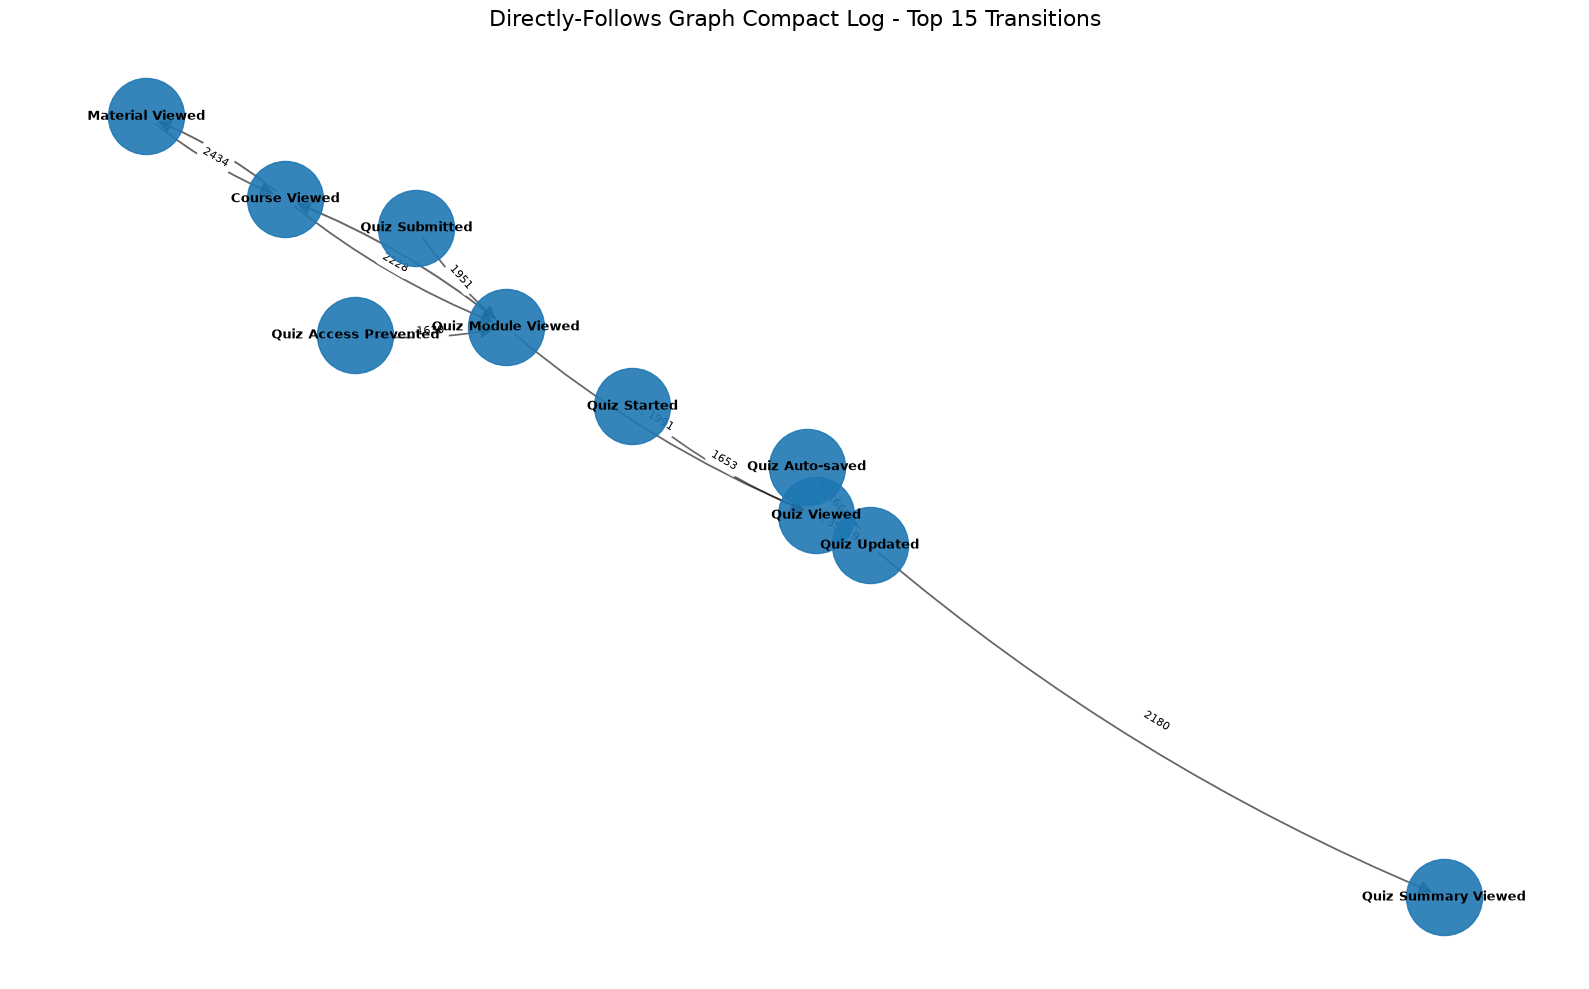

In [9]:
plot_dfg(
    transitions_compact,
    title="Directly-Follows Graph Compact Log - Top 15 Transitions",
    output_path=OUTPUT_FIGURES_DIR / "05_dfg_compact_log_top15.png",
    top_n=15
)

## Cell 10 — Simpan tabel top transisi untuk laporan

In [11]:
top20_full = transitions_full.head(20).copy()
top20_compact = transitions_compact.head(20).copy()

top20_full.to_csv(
    OUTPUT_TABLES_DIR / "05_top20_transitions_full_log.csv",
    index=False
)

top20_compact.to_csv(
    OUTPUT_TABLES_DIR / "05_top20_transitions_compact_log.csv",
    index=False
)

print("Tabel top 20 transisi berhasil disimpan.")
print("Gambar DFG berhasil disimpan di:")
print(OUTPUT_FIGURES_DIR)

Tabel top 20 transisi berhasil disimpan.
Gambar DFG berhasil disimpan di:
e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\figures


## Interpretasi Awal DFG

DFG full log menunjukkan pola transisi utama pada event log process-ready tanpa penyederhanaan repetisi langsung. Pada full log, beberapa transisi self-loop seperti Quiz Viewed → Quiz Viewed dan Quiz Updated → Quiz Updated masih muncul karena LMS mencatat aktivitas teknis yang berulang selama mahasiswa mengerjakan kuis.

DFG compact log digunakan untuk menyederhanakan aktivitas yang sama dan muncul berulang secara langsung pada trace mahasiswa. Setelah proses compacting, pola utama menjadi lebih mudah dibaca, terutama transisi antara Quiz Viewed, Quiz Updated, Quiz Auto-saved, Quiz Summary Viewed, Quiz Submitted, Course Viewed, Material Viewed, dan Quiz Module Viewed.

Hasil ini menunjukkan bahwa aktivitas belajar mahasiswa pada LMS didominasi oleh siklus pengerjaan kuis, dengan pola pendukung berupa akses course, akses material, dan perpindahan menuju modul kuis.

## Cell 11A — Filter transisi utama compact log

In [12]:
main_transitions_compact = transitions_compact[
    transitions_compact["frequency"] >= 1000
].copy()

print("Jumlah transisi compact dengan frequency >= 1000:", len(main_transitions_compact))
display(main_transitions_compact)

Jumlah transisi compact dengan frequency >= 1000: 17


,source,target,frequency
0,Quiz Viewed,Quiz Updated,38709
1,Quiz Updated,Quiz Viewed,35519
2,Quiz Module Viewed,Course Viewed,2990
3,Quiz Updated,Quiz Auto-saved,2864
4,Quiz Auto-saved,Quiz Viewed,2853
5,Course Viewed,Material Viewed,2824
6,Material Viewed,Course Viewed,2434
7,Course Viewed,Quiz Module Viewed,2228
8,Quiz Updated,Quiz Summary Viewed,2180
9,Quiz Module Viewed,Quiz Viewed,1991


## Cell 11B — Plot DFG utama compact log

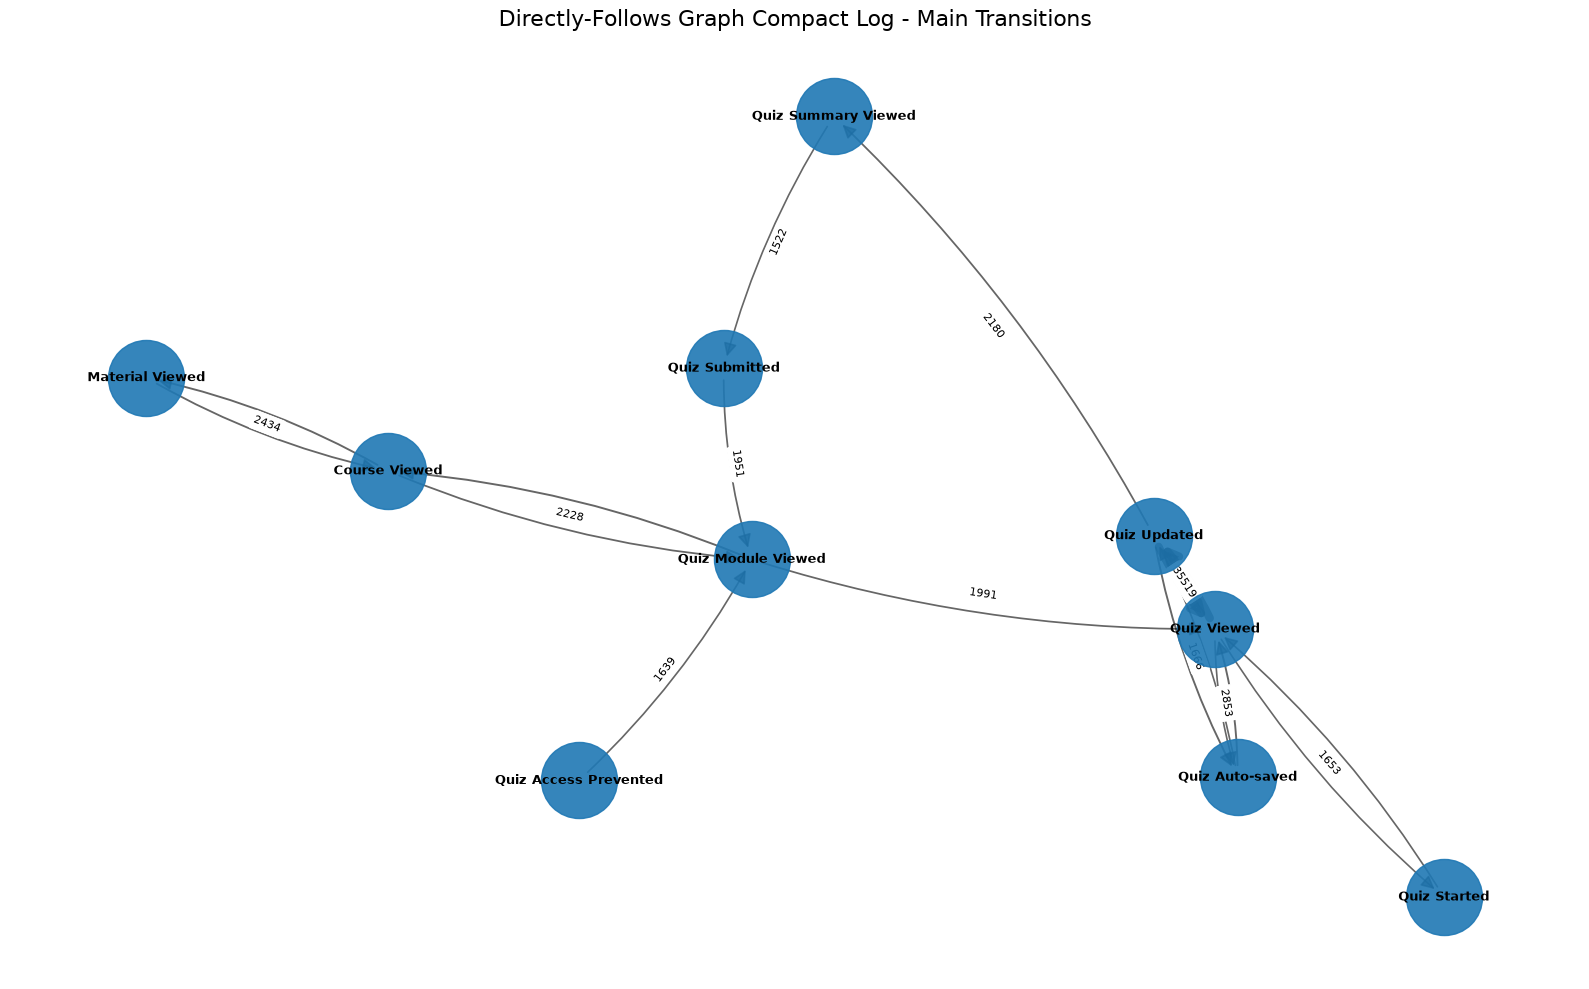

In [13]:
plot_dfg(
    main_transitions_compact,
    title="Directly-Follows Graph Compact Log - Main Transitions",
    output_path=OUTPUT_FIGURES_DIR / "05_dfg_compact_log_main_transitions.png",
    top_n=len(main_transitions_compact)
)

## Cell 11C

In [14]:
excluded_nodes_for_main_dfg = [
    "Assignment Viewed",
    "Assignment Status Viewed",
    "Assignment Form Viewed",
    "Assignment Submitted",
    "Assignment File Uploaded",
    "Assignment Submission Created",
    "Assignment Submission Updated",
    "Assignment Remove Confirmation Viewed",
    "Assignment Submission Removed",
    "Forum Viewed",
    "Forum Subscription Created",
    "Forum Subscription Deleted",
    "Comment Created",
    "Comment Deleted"
]

main_learning_transitions = transitions_compact[
    ~transitions_compact["source"].isin(excluded_nodes_for_main_dfg)
    & ~transitions_compact["target"].isin(excluded_nodes_for_main_dfg)
].copy()

main_learning_transitions = main_learning_transitions[
    main_learning_transitions["frequency"] >= 1000
].copy()

print("Jumlah transisi utama yang ditampilkan:", len(main_learning_transitions))
display(main_learning_transitions)

Jumlah transisi utama yang ditampilkan: 17


,source,target,frequency
0,Quiz Viewed,Quiz Updated,38709
1,Quiz Updated,Quiz Viewed,35519
2,Quiz Module Viewed,Course Viewed,2990
3,Quiz Updated,Quiz Auto-saved,2864
4,Quiz Auto-saved,Quiz Viewed,2853
5,Course Viewed,Material Viewed,2824
6,Material Viewed,Course Viewed,2434
7,Course Viewed,Quiz Module Viewed,2228
8,Quiz Updated,Quiz Summary Viewed,2180
9,Quiz Module Viewed,Quiz Viewed,1991


## Cell 11D

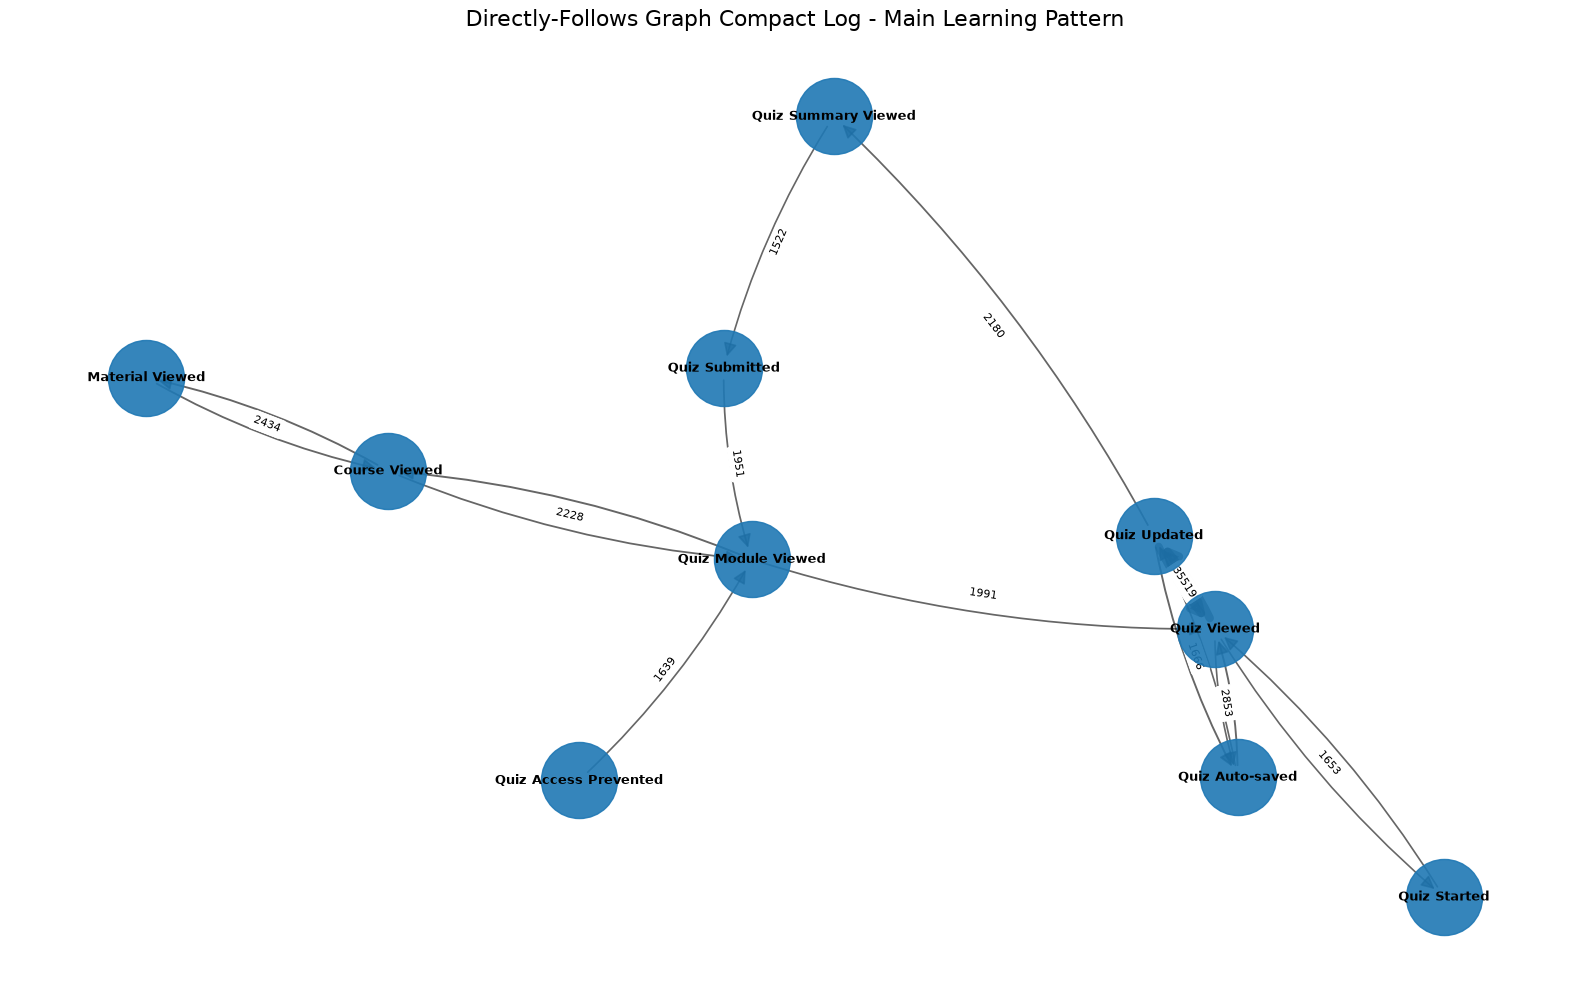

In [15]:
plot_dfg(
    main_learning_transitions,
    title="Directly-Follows Graph Compact Log - Main Learning Pattern",
    output_path=OUTPUT_FIGURES_DIR / "05_dfg_compact_log_main_learning_pattern.png",
    top_n=len(main_learning_transitions)
)

## Cell 11E — DFG dengan layout manual

In [16]:
def plot_dfg_manual_layout(transitions_df, title, output_path=None):
    G = nx.DiGraph()

    for _, row in transitions_df.iterrows():
        source = row["source"]
        target = row["target"]
        frequency = row["frequency"]
        G.add_edge(source, target, weight=frequency)

    # Posisi node dibuat manual supaya alurnya lebih mudah dibaca
    pos = {
        "Course Viewed": (0, 0),
        "Material Viewed": (-1.5, 1),
        "Quiz Module Viewed": (2, 0),
        "Quiz Access Prevented": (1.5, -1.5),
        "Quiz Started": (4, -1.5),
        "Quiz Viewed": (5, 0),
        "Quiz Updated": (6.5, 0),
        "Quiz Auto-saved": (5.8, -1.3),
        "Quiz Summary Viewed": (7.5, 1.5),
        "Quiz Submitted": (4, 1.5),
    }

    # Kalau ada node lain yang belum ada di pos, beri posisi otomatis sederhana
    for i, node in enumerate(G.nodes()):
        if node not in pos:
            pos[node] = (0, -3 - i)

    plt.figure(figsize=(18, 10))

    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    max_weight = max(edge_weights)

    edge_widths = [
        1 + (weight / max_weight) * 5
        for weight in edge_weights
    ]

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=3500,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=22,
        width=edge_widths,
        alpha=0.65,
        connectionstyle="arc3,rad=0.12"
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=10,
        font_weight="bold"
    )

    edge_labels = {
        (u, v): G[u][v]["weight"]
        for u, v in G.edges()
    }

    nx.draw_networkx_edge_labels(
        G,
        pos,
        edge_labels=edge_labels,
        font_size=8,
        rotate=False
    )

    plt.title(title, fontsize=16)
    plt.axis("off")
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

## Cell 11F — Plot manual layout

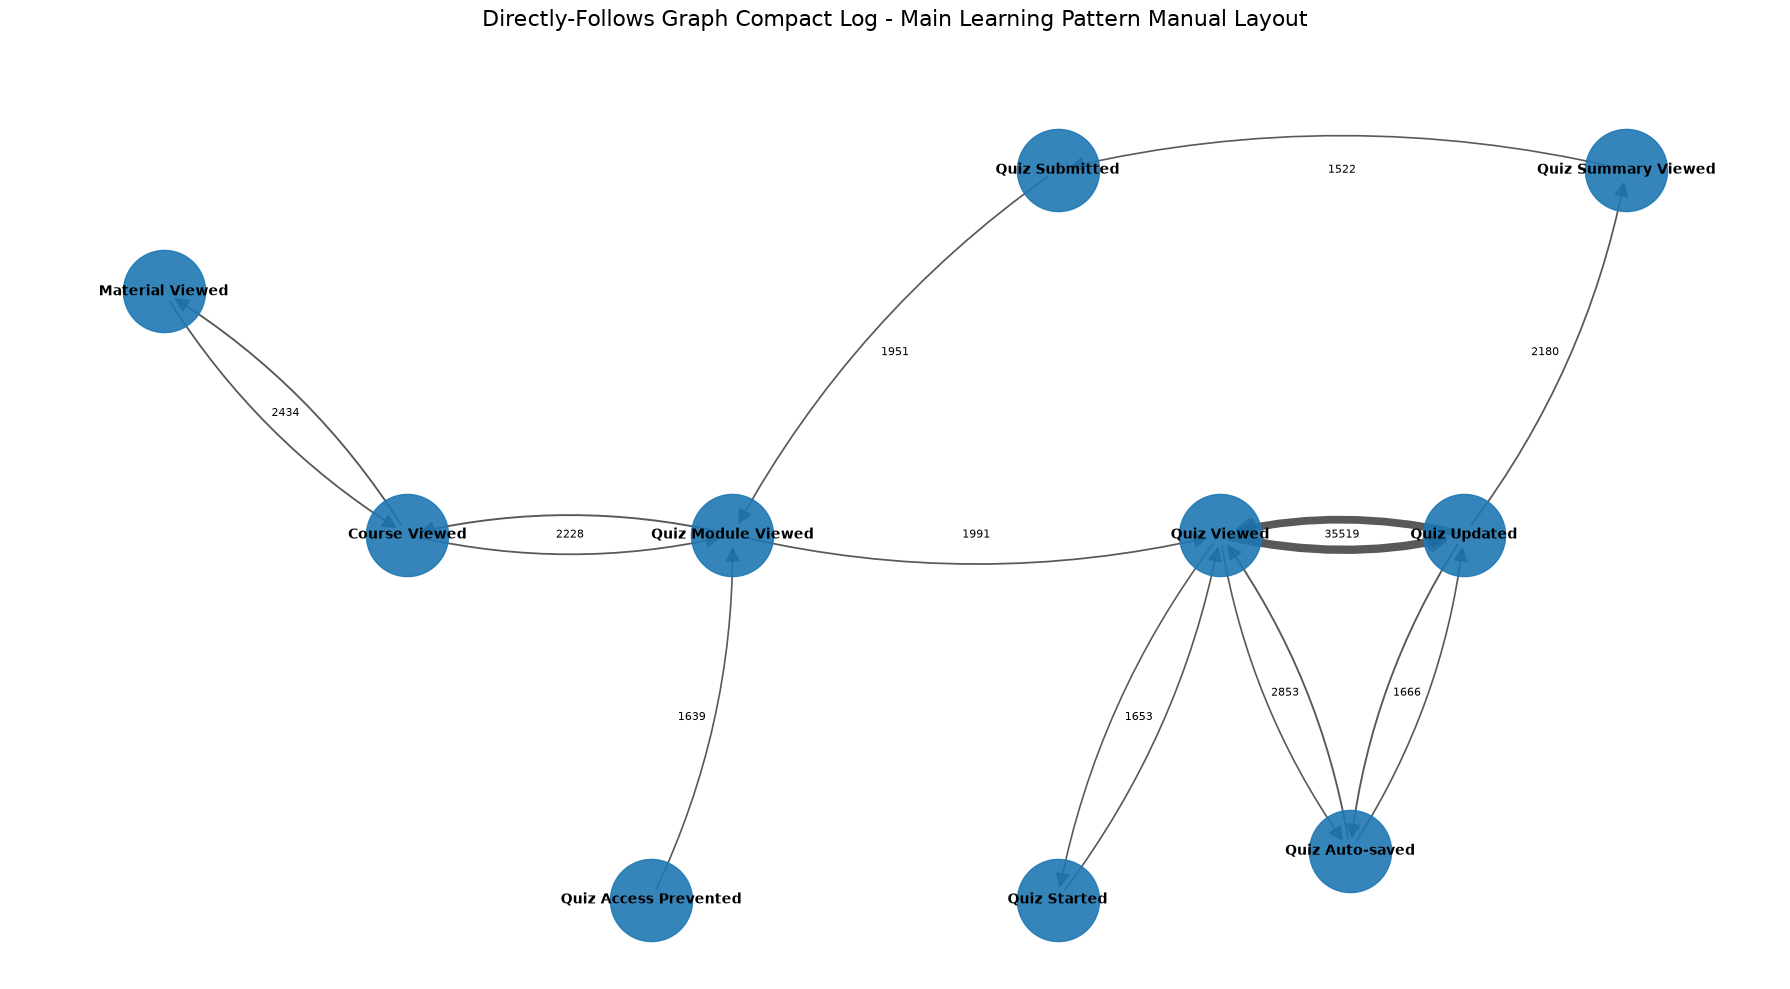

In [17]:
plot_dfg_manual_layout(
    main_learning_transitions,
    title="Directly-Follows Graph Compact Log - Main Learning Pattern Manual Layout",
    output_path=OUTPUT_FIGURES_DIR / "05_dfg_compact_log_main_learning_pattern_manual_layout.png"
)

## Cell 11G -- DFG tanpa edge label

In [18]:
def plot_dfg_manual_layout_clean(transitions_df, title, output_path=None):
    G = nx.DiGraph()

    for _, row in transitions_df.iterrows():
        source = row["source"]
        target = row["target"]
        frequency = row["frequency"]
        G.add_edge(source, target, weight=frequency)

    pos = {
        "Course Viewed": (0, 0),
        "Material Viewed": (-1.5, 1),
        "Quiz Module Viewed": (2, 0),
        "Quiz Access Prevented": (1.5, -1.5),
        "Quiz Started": (4, -1.5),
        "Quiz Viewed": (5.2, 0),
        "Quiz Updated": (6.8, 0),
        "Quiz Auto-saved": (6.2, -1.4),
        "Quiz Summary Viewed": (8.2, 1.5),
        "Quiz Submitted": (4.5, 1.5),
    }

    for i, node in enumerate(G.nodes()):
        if node not in pos:
            pos[node] = (0, -3 - i)

    plt.figure(figsize=(18, 10))

    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    max_weight = max(edge_weights)

    edge_widths = [
        1 + (weight / max_weight) * 5
        for weight in edge_weights
    ]

    nx.draw_networkx_nodes(
        G,
        pos,
        node_size=3600,
        alpha=0.9
    )

    nx.draw_networkx_edges(
        G,
        pos,
        arrows=True,
        arrowstyle="-|>",
        arrowsize=22,
        width=edge_widths,
        alpha=0.65,
        connectionstyle="arc3,rad=0.13"
    )

    nx.draw_networkx_labels(
        G,
        pos,
        font_size=10,
        font_weight="bold"
    )

    plt.title(title, fontsize=16)
    plt.axis("off")
    plt.tight_layout()

    if output_path is not None:
        plt.savefig(output_path, dpi=300, bbox_inches="tight")

    plt.show()

## Cell 11H

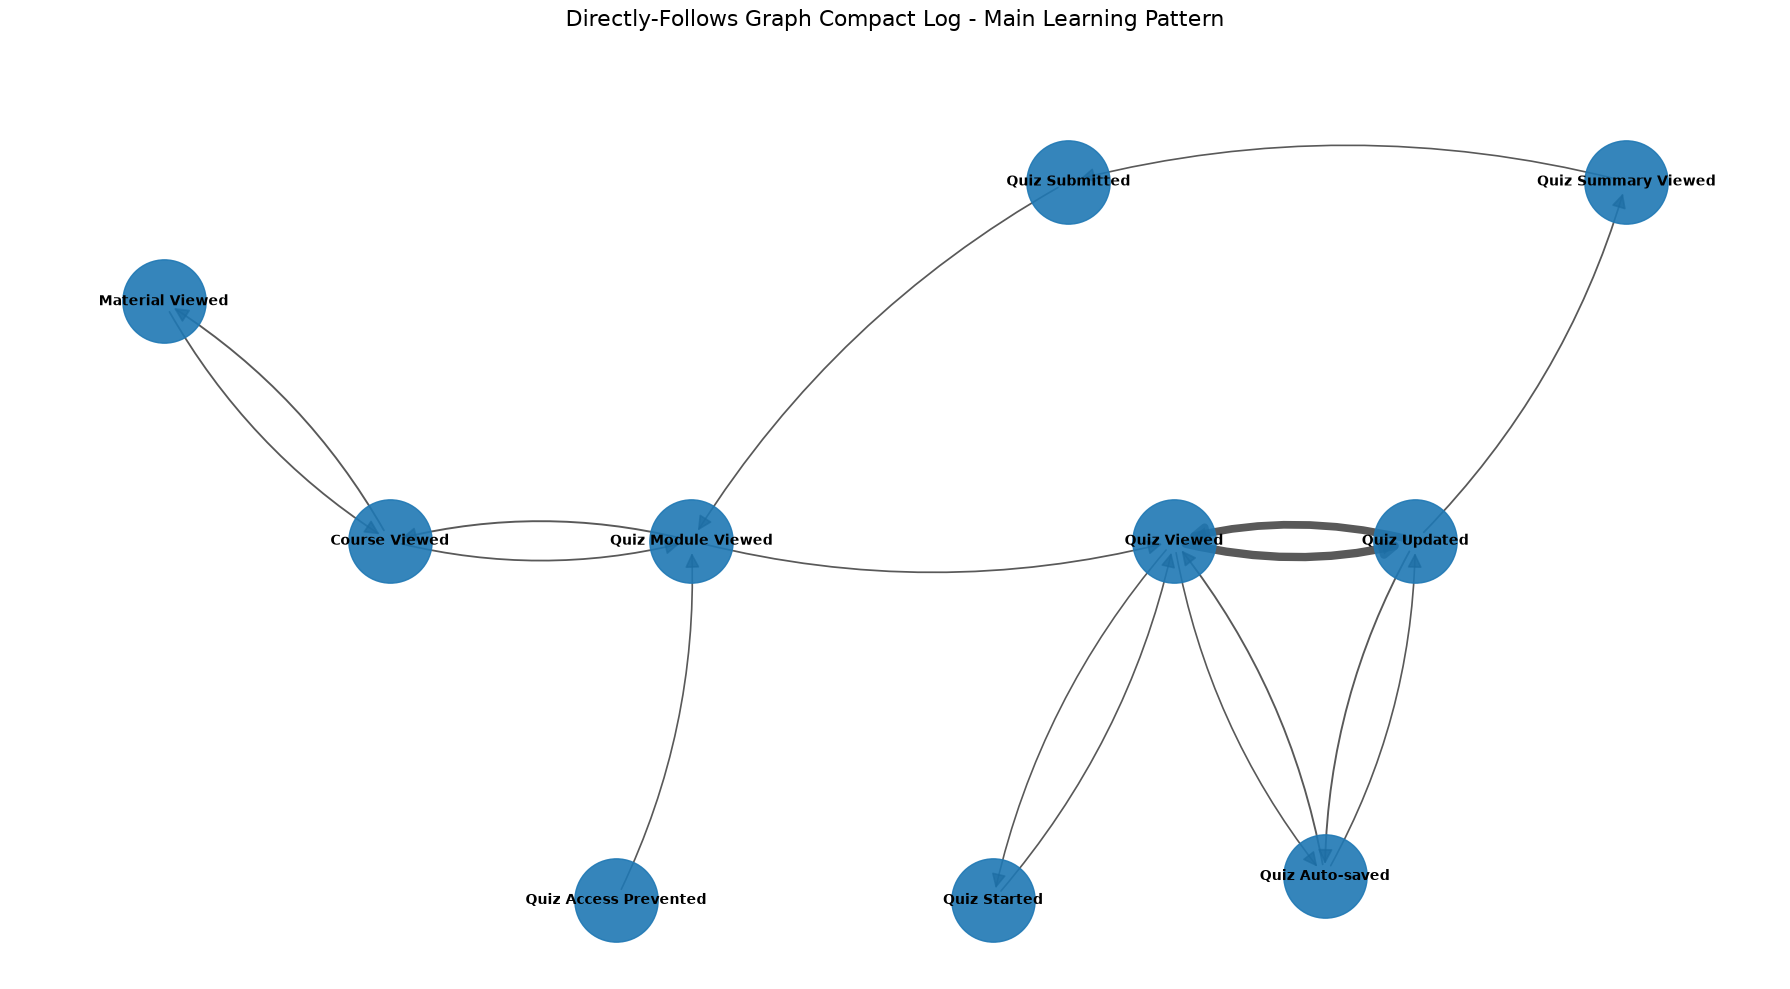

In [19]:
plot_dfg_manual_layout_clean(
    main_learning_transitions,
    title="Directly-Follows Graph Compact Log - Main Learning Pattern",
    output_path=OUTPUT_FIGURES_DIR / "05_dfg_compact_log_main_learning_pattern_clean.png"
)

## Cell 11I — Simpan transisi utama

In [20]:
MAIN_LEARNING_TRANSITIONS_PATH = OUTPUT_TABLES_DIR / "05_main_learning_transitions_compact_log.csv"

main_learning_transitions.to_csv(
    MAIN_LEARNING_TRANSITIONS_PATH,
    index=False
)

print("Tabel main learning transitions berhasil disimpan ke:")
print(MAIN_LEARNING_TRANSITIONS_PATH)

Tabel main learning transitions berhasil disimpan ke:
e:\Tugas Akhir\Coding\TA_PROCESS_MINING_FINAL\outputs\tables\05_main_learning_transitions_compact_log.csv


## Kesimpulan DFG Visualization

Pada tahap ini, Directly-Follows Graph (DFG) dibentuk dari full log dan compact log. Full log masih menunjukkan adanya repetisi langsung pada aktivitas tertentu, terutama pada aktivitas kuis. Oleh karena itu, compact log digunakan untuk menyederhanakan aktivitas yang sama dan muncul berulang secara langsung dalam trace mahasiswa.

Visualisasi DFG compact log menunjukkan bahwa pola utama proses belajar mahasiswa didominasi oleh aktivitas kuis. Alur utama dimulai dari Course Viewed, kemudian berlanjut ke Material Viewed atau Quiz Module Viewed. Setelah itu, mahasiswa masuk ke siklus pengerjaan kuis yang melibatkan Quiz Started, Quiz Viewed, Quiz Updated, dan Quiz Auto-saved. Pola paling dominan terlihat pada hubungan bolak-balik antara Quiz Viewed dan Quiz Updated.

Untuk menjaga keterbacaan visualisasi, DFG utama difokuskan pada transisi dengan frekuensi tinggi pada compact log. Transisi lain yang memiliki frekuensi lebih rendah tetap disimpan dalam tabel transisi sebagai data pendukung. Gambar utama yang digunakan untuk interpretasi adalah DFG compact log dengan main learning pattern.